# Bước 04 — DDIM sampling (nhanh hơn DDPM)

Notebook giải thích từng phần của [`04_sample_ddim.py`](./04_sample_ddim.py).

**Mục tiêu:** Cùng UNet bước 02, **đổi cách sample** — nhảy cóc timestep thay vì 1000 bước liên tiếp.

| Khái niệm | Ý nghĩa nhanh |
|-----------|----------------|
| DDIM | Denoising Diffusion **Implicit** Models |
| `num_steps=50` | Chỉ ~50 lần gọi UNet (thay 1000) |
| `eta=0` | Deterministic — cùng noise đầu → cùng ảnh |
| `ddim_sample` | Nhảy `x_t → x_{t_prev}` (bước cách đều trên timeline) |
| Train | **Không đổi** — vẫn dùng `ddpm_mnist.pt` |

**Điều kiện:** checkpoint `assets/ddpm_mnist.pt` (bước 02).

> Liên hệ SwiftEdit / SD: pipeline thực tế thường dùng **few-step** (DDIM, DPM-Solver…) thay full 1000-step — chất lượng gần tương đương, nhanh hơn nhiều.

## 0. Setup

In [1]:
%matplotlib inline

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "diffusion" / "schedule.py").exists():
    raise FileNotFoundError(
        f"Không thấy diffusion/schedule.py trong {ROOT}.\n"
        "Mở notebook từ learn/diffusion-from-scratch/ hoặc cd vào đó trước."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from diffusion import LinearSchedule, UNet
from diffusion.utils import set_seed, get_device

set_seed(42)
device = get_device()
assets_dir = ROOT / "assets"
assets_dir.mkdir(exist_ok=True)
CHECKPOINT = assets_dir / "ddpm_mnist.pt"
T = 1000

print("ROOT:", ROOT)
print("Device:", device)
print("Checkpoint:", "OK" if CHECKPOINT.exists() else "THIẾU — chạy bước 02")

ROOT: /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch
Device: mps
Checkpoint: OK


## 1. DDPM vs DDIM — cùng model, khác quy trình sample

| | DDPM (bước 03) | DDIM (bước 04) |
|--|----------------|----------------|
| Số bước UNet/ảnh | 1000 | 50 hoặc 20 (tùy chọn) |
| Timestep | Mỗi `t`: 999, 998, …, 0 | **Nhảy cóc** (subsequence) |
| Hàm | `p_sample` | `ddim_sample` |
| Randomness | Có noise mỗi bước (`t>0`) | `eta=0` → **deterministic** |
| Train lại? | Không | Không |

**Ý chính DDIM:** UNet vẫn predict noise → suy ra `x_0` tạm thời → nhảy thẳng tới `x_{t_prev}` trên timeline thưa hơn.

## 2. Load model + lịch timestep DDIM

Script tạo dãy timestep **cách đều** từ `T-1` về `0`:

```python
step_size = T // num_steps
timesteps = [999, 979, 959, ..., 0]   # num_steps=50
```

In [2]:
if not CHECKPOINT.exists():
    raise FileNotFoundError(f"Thiếu {CHECKPOINT} — chạy bước 02 trước.")

schedule = LinearSchedule(T=T, device=device)
model = UNet(in_ch=1, base_ch=32, time_dim=128).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location=device, weights_only=True))
model.eval()


def make_ddim_timesteps(num_steps, T=1000):
    step_size = T // num_steps
    return list(range(T - 1, -1, -step_size))


for num_steps in [50, 20]:
    ts = make_ddim_timesteps(num_steps)
    print(f"num_steps={num_steps}: {len(ts)} bước, đầu={ts[:5]}, cuối={ts[-3:]}")

num_steps=50: 50 bước, đầu=[999, 979, 959, 939, 919], cuối=[59, 39, 19]
num_steps=20: 20 bước, đầu=[999, 949, 899, 849, 799], cuối=[149, 99, 49]


## 3. Một bước `ddim_sample` — nhảy `t → t_prev`

Khác `p_sample` (chỉ lùi 1 bước), `ddim_sample` nhảy từ `t` sang `t_prev` xa hơn:

1. `eps_pred = model(x_t, t)`
2. Suy ra `x_0` tạm (predicted clean image)
3. Tính `x_{t_prev}` từ `x_0` + hướng noise (`eta=0` → không thêm random)

Nhảy t=999 → t_prev=979
alpha_bar: 0.000 → 0.000


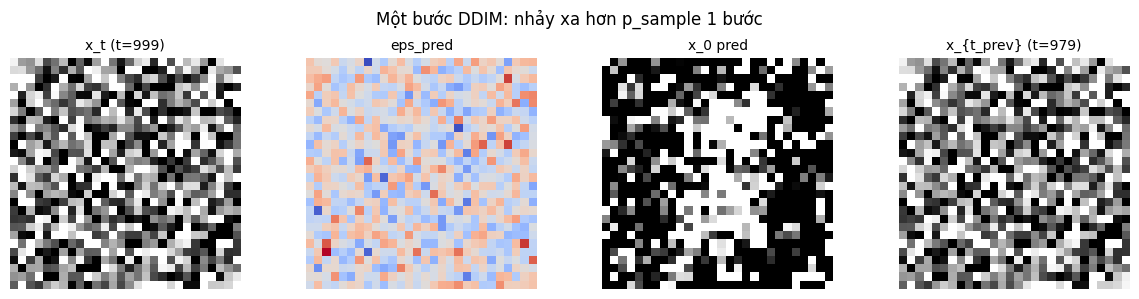

In [3]:
timesteps_50 = make_ddim_timesteps(50)
t, t_prev = timesteps_50[0], timesteps_50[1]  # vd: 999 → 979

x_t = torch.randn(1, 1, 28, 28, device=device)

with torch.no_grad():
    eps_pred = model(x_t, torch.tensor([t], device=device))
    x_prev = schedule.ddim_sample(model, x_t, t, t_prev, eta=0.0)
    ab_t = schedule.alpha_bar[t].item()
    ab_prev = schedule.alpha_bar[t_prev].item()
    x0_pred = ((x_t - schedule.sqrt_one_minus_alpha_bar[t] * eps_pred)
               / schedule.sqrt_alpha_bar[t]).clamp(-1, 1)

print(f"Nhảy t={t} → t_prev={t_prev}")
print(f"alpha_bar: {ab_t:.3f} → {ab_prev:.3f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
panels = [
    (x_t, f"x_t (t={t})"),
    (eps_pred, "eps_pred"),
    (x0_pred, "x_0 pred"),
    (x_prev, f"x_{{t_prev}} (t={t_prev})"),
]
for ax, (tensor, title) in zip(axes, panels):
    img = tensor.squeeze().cpu().numpy()
    if "eps" in title:
        ax.imshow(img, cmap="coolwarm")
    else:
        ax.imshow((img + 1) / 2, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.suptitle("Một bước DDIM: nhảy xa hơn p_sample 1 bước", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Hàm `sample_ddim` — giống script gốc

In [4]:
@torch.no_grad()
def sample_ddim(model, schedule, n_samples=16, num_steps=50, eta=0.0, device="cpu"):
    """DDIM sampling (giống 04_sample_ddim.py)."""
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    step_size = schedule.T // num_steps
    timesteps = list(range(schedule.T - 1, -1, -step_size))

    for i in tqdm(range(len(timesteps)), desc=f"DDIM {num_steps} steps"):
        t = timesteps[i]
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        x = schedule.ddim_sample(model, x, t, t_prev, eta=eta)

    return (x.clamp(-1, 1) + 1) / 2


def show_samples(samples, title, save_name):
    n = min(len(samples), 16)
    nrow = 4
    fig, axes = plt.subplots(nrow, nrow, figsize=(6, 6))
    fig.suptitle(title, fontsize=13)
    for ax, img in zip(axes.flat, samples[:n]):
        ax.imshow(img.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    for ax in axes.flat[n:]:
        ax.axis("off")
    fig.tight_layout()
    path = assets_dir / save_name
    fig.savefig(path, dpi=150)
    print(f"Đã lưu → {path}")
    plt.show()

## 5. Sinh ảnh — DDIM 50 bước

Script gốc: 64 ảnh. Notebook: `N_SAMPLES=16` cho nhanh.

DDIM 50 steps: 100%|██████████| 50/50 [00:02<00:00, 22.61it/s]


DDIM 50 steps: 2.3s cho 16 ảnh
Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/ddim_50_samples_notebook.png


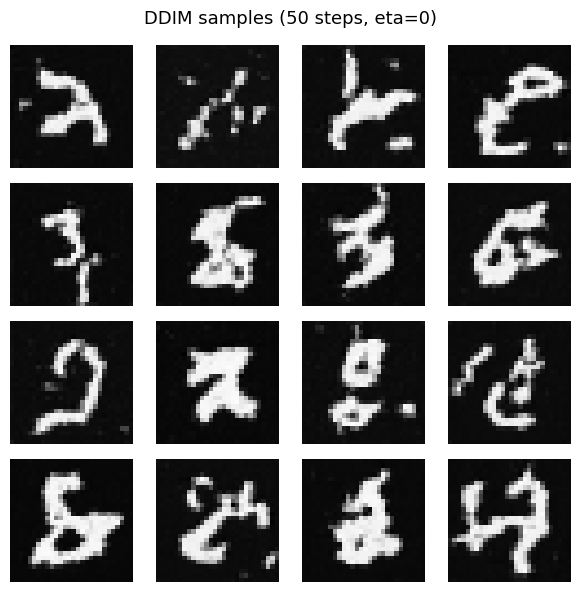

In [5]:
N_SAMPLES = 16

t0 = time.time()
samples_50 = sample_ddim(model, schedule, n_samples=N_SAMPLES, num_steps=50, device=device)
elapsed_50 = time.time() - t0
print(f"DDIM 50 steps: {elapsed_50:.1f}s cho {N_SAMPLES} ảnh")

show_samples(samples_50, "DDIM samples (50 steps, eta=0)", "ddim_50_samples_notebook.png")

## 6. Sinh ảnh — DDIM 20 bước (nhanh hơn nữa)

Ít bước hơn → nhanh hơn, chất lượng có thể giảm nhẹ (so với 50 hoặc DDPM 1000).

DDIM 20 steps: 100%|██████████| 20/20 [00:00<00:00, 83.11it/s]


DDIM 20 steps: 0.2s cho 16 ảnh
Tốc độ ~ 9.7x so với 50 steps (ước lượng)
Đã lưu → /Users/nguyenkz/Documents/code/CS2309.CH201/learn/diffusion-from-scratch/assets/ddim_20_samples_notebook.png


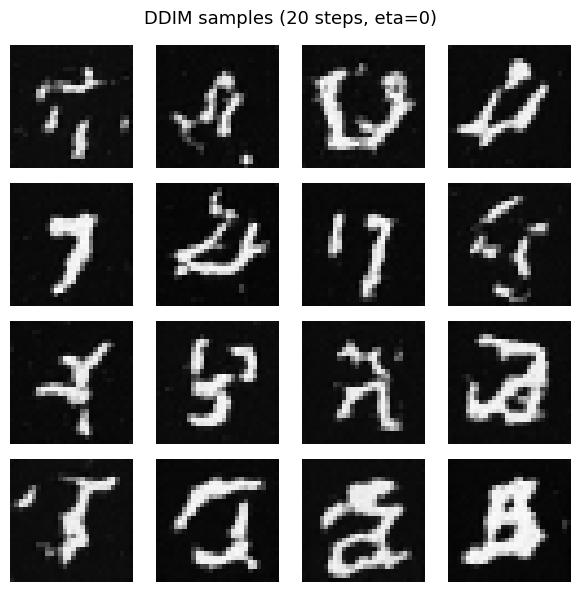

In [8]:
t0 = time.time()
samples_20 = sample_ddim(model, schedule, n_samples=N_SAMPLES, num_steps=20, device=device)
elapsed_20 = time.time() - t0
print(f"DDIM 20 steps: {elapsed_20:.1f}s cho {N_SAMPLES} ảnh")
print(f"Tốc độ ~ {elapsed_50/elapsed_20:.1f}x so với 50 steps (ước lượng)")

show_samples(samples_20, "DDIM samples (20 steps, eta=0)", "ddim_20_samples_notebook.png")

## 7. So sánh nhanh 50 vs 20 steps (cùng seed)

Với `eta=0`, DDIM deterministic — cùng noise đầu → cùng ảnh. Cell dưới sinh **1 ảnh** hai cách để so trực quan.

DDIM 20 steps: 100%|██████████| 20/20 [00:00<00:00, 141.02it/s]


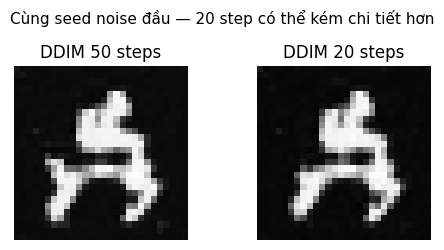

In [9]:
set_seed(123)
one_50 = sample_ddim(model, schedule, n_samples=1, num_steps=50, device=device)
set_seed(123)
one_20 = sample_ddim(model, schedule, n_samples=1, num_steps=20, device=device)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(one_50.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("DDIM 50 steps")
axes[0].axis("off")
axes[1].imshow(one_20.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("DDIM 20 steps")
axes[1].axis("off")
plt.suptitle("Cùng seed noise đầu — 20 step có thể kém chi tiết hơn", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Tóm tắt — hoàn thành pipeline `diffusion-from-scratch`

### Bạn vừa học được

1. **DDIM** = cùng UNet DDPM, sample nhanh bằng timestep thưa.
2. `eta=0` → deterministic (quan trọng cho inversion / editing ổn định).
3. Trade-off: 1000 (DDPM) vs 50 vs 20 bước — tốc độ vs chất lượng.

### Toàn bộ pipeline

| Bước | File | Việc |
|------|------|------|
| 01 | forward | Phá ảnh → `x_t` |
| 02 | train | UNet học predict noise |
| 03 | DDPM sample | 1000 bước, chậm, chuẩn |
| 04 | DDIM sample | 50/20 bước, nhanh |

### SwiftEdit (CS2309)

- SD editing thực tế dùng **few-step denoise** trong latent (giống tinh thần DDIM).
- Method cũ: **DDIM inversion** multi-step để tìm noise từ ảnh.
- **SwiftEdit:** `F_theta` thay inversion bằng **1 forward pass** — vẫn cần hiểu noise/latent/timestep.

**Checklist:**

- [ ] Giải thích vì sao DDIM không cần train lại
- [ ] Biết `eta=0` nghĩa là gì
- [ ] So sánh được DDPM vs DDIM về tốc độ

→ Quay lại [`tasks/theory_tasks.md`](../../tasks/theory_tasks.md) hoặc [`README.md`](./README.md).